In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP1_AB_5fold_results.csv")

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS
drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)

# FEATURES AND TARGET
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()

# MODELS
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}

# 5-FOLD STRATIFIED CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 25)

Results using dataset + W1 V1 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.697827,0.005671,0.695899,0.005794,0.697827,0.005671,0.695297,0.005569
1,CP1,DecisionTree,0.720699,0.002921,0.721584,0.002855,0.720699,0.002921,0.721054,0.002898
2,CP1,RandomForest,0.759374,0.002473,0.758621,0.002633,0.759374,0.002473,0.757696,0.002187
3,CP1,GradientBoosting,0.785781,0.003823,0.795687,0.004714,0.785781,0.003823,0.779549,0.003833
4,CP1,XGBoost,0.785822,0.002987,0.792270,0.004210,0.785822,0.002987,0.780827,0.002830
5,CP1,NeuralNetwork_MLP,0.757302,0.004116,0.758298,0.004882,0.757302,0.004116,0.754337,0.003028


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP1_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP2_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 27)

Results using dataset + W1 V1 W2 V2 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.787853,0.003077,0.790811,0.003089,0.787853,0.003077,0.784372,0.003273
1,CP1,DecisionTree,0.765387,0.004628,0.765909,0.004623,0.765387,0.004628,0.765588,0.004612
2,CP1,RandomForest,0.816697,0.004603,0.818043,0.004889,0.816697,0.004603,0.814816,0.004602
3,CP1,GradientBoosting,0.828235,0.005112,0.835532,0.005319,0.828235,0.005112,0.824749,0.005279
4,CP1,XGBoost,0.829088,0.003347,0.834669,0.003595,0.829088,0.003347,0.826089,0.003435
5,CP1,NeuralNetwork_MLP,0.821491,0.006216,0.829347,0.004533,0.821491,0.006216,0.817628,0.007213


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP2_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP3_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 29)

Results using dataset + W1 V1 W2 V2 W3 V3 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.812797,0.003762,0.815377,0.003446,0.812797,0.003762,0.810292,0.004031
1,CP1,DecisionTree,0.785415,0.008804,0.785941,0.008716,0.785415,0.008804,0.785617,0.008767
2,CP1,RandomForest,0.838960,0.005255,0.841221,0.005489,0.838960,0.005255,0.837209,0.005317
3,CP1,GradientBoosting,0.846963,0.003122,0.852171,0.003293,0.846963,0.003122,0.844574,0.003197
4,CP1,XGBoost,0.845663,0.003349,0.850255,0.003200,0.845663,0.003349,0.843390,0.003506
5,CP1,NeuralNetwork_MLP,0.837701,0.002695,0.842691,0.002020,0.837701,0.002695,0.835144,0.003242


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP3_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP4_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3", "W_4", "V_4"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 W4 V4 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 31)

Results using dataset + W1 V1 W2 V2 W3 V3 W4 V4 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.862929,0.006059,0.867357,0.006790,0.862929,0.006059,0.861106,0.006028
1,CP1,DecisionTree,0.828235,0.004429,0.828633,0.004205,0.828235,0.004429,0.828382,0.004359
2,CP1,RandomForest,0.882226,0.002535,0.884797,0.003444,0.882226,0.002535,0.881142,0.002392
3,CP1,GradientBoosting,0.884867,0.002408,0.889283,0.003236,0.884867,0.002408,0.883472,0.002339
4,CP1,XGBoost,0.883689,0.003676,0.887803,0.004428,0.883689,0.003676,0.882327,0.003613
5,CP1,NeuralNetwork_MLP,0.877229,0.003810,0.880551,0.005608,0.877229,0.003810,0.875943,0.003535


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP4_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP5_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3", "W_4", "V_4", "W_5", "V_5"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 33)

Results using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.884258,0.005568,0.887244,0.006144,0.884258,0.005568,0.883114,0.005531
1,CP1,DecisionTree,0.849766,0.005866,0.850109,0.005834,0.849766,0.005866,0.849890,0.005853
2,CP1,RandomForest,0.898883,0.003979,0.901257,0.004395,0.898883,0.003979,0.898050,0.003966
3,CP1,GradientBoosting,0.898680,0.004138,0.900925,0.004509,0.898680,0.004138,0.897867,0.004132
4,CP1,XGBoost,0.898761,0.003541,0.901402,0.003862,0.898761,0.003541,0.897878,0.003541
5,CP1,NeuralNetwork_MLP,0.893114,0.003044,0.896027,0.002623,0.893114,0.003044,0.892112,0.003201


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP5_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP6_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3", "W_4", "V_4", "W_5", "V_5", "W_6", "V_6"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 35)

Results using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.909567,0.004265,0.910820,0.004218,0.909567,0.004265,0.909041,0.004311
1,CP1,DecisionTree,0.877554,0.004801,0.877771,0.004728,0.877554,0.004801,0.877631,0.004778
2,CP1,RandomForest,0.918952,0.001830,0.920494,0.001856,0.918952,0.001830,0.918458,0.001848
3,CP1,GradientBoosting,0.918099,0.003691,0.919296,0.003588,0.918099,0.003691,0.917653,0.003738
4,CP1,XGBoost,0.918139,0.003464,0.919591,0.003496,0.918139,0.003464,0.917654,0.003490
5,CP1,NeuralNetwork_MLP,0.914808,0.002584,0.916478,0.002741,0.914808,0.002584,0.914257,0.002583


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP6_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP7_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3", "W_4", "V_4", "W_5", "V_5", "W_6", "V_6", "W_7", "V_7"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 37)

Results using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.917449,0.002813,0.918291,0.002660,0.917449,0.002813,0.917066,0.002866
1,CP1,DecisionTree,0.892992,0.002702,0.893219,0.002783,0.892992,0.002702,0.893068,0.002724
2,CP1,RandomForest,0.926630,0.002245,0.927782,0.002338,0.926630,0.002245,0.926255,0.002247
3,CP1,GradientBoosting,0.926589,0.002778,0.927434,0.002819,0.926589,0.002778,0.926266,0.002788
4,CP1,XGBoost,0.926021,0.002795,0.926836,0.002742,0.926021,0.002795,0.925697,0.002822
5,CP1,NeuralNetwork_MLP,0.922568,0.003637,0.923351,0.003494,0.922568,0.003637,0.922230,0.003694


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP7_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP8_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3", "W_4", "V_4", "W_5", "V_5", "W_6", "V_6", "W_7", "V_7", "W_8", "V_8"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 W8 V8 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 39)

Results using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 W8 V8 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.923421,0.002623,0.923921,0.002633,0.923421,0.002623,0.923143,0.002635
1,CP1,DecisionTree,0.896892,0.003608,0.897106,0.003554,0.896892,0.003608,0.896964,0.003589
2,CP1,RandomForest,0.934308,0.002796,0.935203,0.002819,0.934308,0.002796,0.934021,0.002808
3,CP1,GradientBoosting,0.933090,0.003135,0.933580,0.003185,0.933090,0.003135,0.932864,0.003141
4,CP1,XGBoost,0.934430,0.002093,0.935030,0.002175,0.934430,0.002093,0.934192,0.002089
5,CP1,NeuralNetwork_MLP,0.929149,0.003994,0.930061,0.004331,0.929149,0.003994,0.928839,0.003971


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP8_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP9_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3", "W_4", "V_4", "W_5", "V_5", "W_6", "V_6", "W_7", "V_7", "W_8", "V_8", "W_9", "V_9"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 W8 V8 W9 V9 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 41)

Results using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 W8 V8 W9 V9 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.924274,0.001777,0.924778,0.001793,0.924274,0.001777,0.924000,0.001783
1,CP1,DecisionTree,0.898192,0.003812,0.898341,0.003780,0.898192,0.003812,0.898238,0.003789
2,CP1,RandomForest,0.934471,0.002984,0.935413,0.003089,0.934471,0.002984,0.934179,0.002987
3,CP1,GradientBoosting,0.932968,0.002938,0.933471,0.003026,0.932968,0.002938,0.932740,0.002935
4,CP1,XGBoost,0.933455,0.002894,0.934015,0.002918,0.933455,0.002894,0.933218,0.002905
5,CP1,NeuralNetwork_MLP,0.929352,0.002542,0.930109,0.002562,0.929352,0.002542,0.929067,0.002558


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP9_AB_5fold_results.csv


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


# PATHS

INPUT = "/content/drive/MyDrive/research/dataset2_αβ.csv"
OUTDIR = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"
os.makedirs(OUTDIR, exist_ok=True)

OUT = os.path.join(OUTDIR, "CP10_AB_5fold_results.csv")


# LOAD DATA

df = pd.read_csv(INPUT)

print("Original shape:", df.shape)

TARGET_COL = "final_result"


# REMOVE UNWANTED COLUMNS

drop_cols = [
    "id_student",
    "code_module",
    "code_presentation",
    "assessment_grade",
    "VLE_normalized"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])


# KEEP ONLY W1 AND V1

grade_cols = [c for c in df.columns if c.startswith("W_") or c.startswith("V_")]
remove_grades = [c for c in grade_cols if c not in ["W_1", "V_1", "W_2", "V_2", "W_3", "V_3", "W_4", "V_4", "W_5", "V_5", "W_6", "V_6", "W_7", "V_7", "W_8", "V_8", "W_9", "V_9", "W_10", "V_10"]]
df = df.drop(columns=remove_grades)

print("Shape after cleaning:", df.shape)


# FEATURES AND TARGET

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()


# MODELS

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    ),
    "NeuralNetwork_MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    )
}


# 5-FOLD STRATIFIED CV

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_test = y.iloc[test_idx].copy()

        num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in X_train.columns if c not in num_cols]

        numeric_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_tf = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])

        preprocess = ColumnTransformer([
            ("num", numeric_tf, num_cols),
            ("cat", categorical_tf, cat_cols)
        ])

        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", clone(model))
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        precision_scores.append(precision_score(y_test, pred, average="weighted", zero_division=0))
        recall_scores.append(recall_score(y_test, pred, average="weighted", zero_division=0))
        f1_scores.append(f1_score(y_test, pred, average="weighted", zero_division=0))

    results.append({
        "Checkpoint": "CP1",
        "Model": name,
        "Accuracy_mean": np.mean(acc_scores),
        "Accuracy_std": np.std(acc_scores),
        "Precision_mean": np.mean(precision_scores),
        "Precision_std": np.std(precision_scores),
        "Recall_mean": np.mean(recall_scores),
        "Recall_std": np.std(recall_scores),
        "F1_mean": np.mean(f1_scores),
        "F1_std": np.std(f1_scores)
    })

results_df = pd.DataFrame(results)

print("\nResults using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 W8 V8 W9 V9 W10 V10 only with 5-fold stratified CV\n")
display(results_df)

results_df.to_csv(OUT, index=False)

print("Saved:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original shape: (24615, 48)
Shape after cleaning: (24615, 43)

Results using dataset + W1 V1 W2 V2 W3 V3 W4 V4 W5 V5 W6 V6 W7 V7 W8 V8 W9 V9 W10 V10 only with 5-fold stratified CV



,Checkpoint,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,CP1,LogisticRegression,0.924477,0.001782,0.924970,0.001802,0.924477,0.001782,0.924207,0.001787
1,CP1,DecisionTree,0.897908,0.001908,0.898081,0.001859,0.897908,0.001908,0.897959,0.001885
2,CP1,RandomForest,0.935446,0.003436,0.936317,0.003460,0.935446,0.003436,0.935169,0.003452
3,CP1,GradientBoosting,0.933171,0.002448,0.933678,0.002514,0.933171,0.002448,0.932943,0.002447
4,CP1,XGBoost,0.934755,0.002167,0.935340,0.002164,0.934755,0.002167,0.934520,0.002178
5,CP1,NeuralNetwork_MLP,0.930530,0.003040,0.930885,0.003157,0.930530,0.003040,0.930325,0.003030


Saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/CP10_AB_5fold_results.csv


In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS"

all_results = []

for i in range(1, 11):
    file_path = os.path.join(base_path, f"CP{i}_AB_5fold_results.csv")

    df = pd.read_csv(file_path)

    df["Day_count"] = 26 * i

    df = df.rename(columns={
        "Accuracy_mean": "Validation_accuracy",
        "Precision_mean": "Validation_precision",
        "Recall_mean": "Validation_recall",
        "F1_mean": "Validation_F1"
    })

    all_results.append(df)

merged_df = pd.concat(all_results, ignore_index=True)

OUT_TOP = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/ML2_AB_5fold_merged.csv"
merged_df.to_csv(OUT_TOP, index=False)

print("Merged file saved:", OUT_TOP)
display(merged_df.head())

Merged file saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/ML2_AB_5fold_merged.csv


,Checkpoint,Model,Validation_accuracy,Accuracy_std,Validation_precision,Precision_std,Validation_recall,Recall_std,Validation_F1,F1_std,Day_count
0,CP1,LogisticRegression,0.697827,0.005671,0.695899,0.005794,0.697827,0.005671,0.695297,0.005569,26
1,CP1,DecisionTree,0.720699,0.002921,0.721584,0.002855,0.720699,0.002921,0.721054,0.002898,26
2,CP1,RandomForest,0.759374,0.002473,0.758621,0.002633,0.759374,0.002473,0.757696,0.002187,26
3,CP1,GradientBoosting,0.785781,0.003823,0.795687,0.004714,0.785781,0.003823,0.779549,0.003833,26
4,CP1,XGBoost,0.785822,0.002987,0.792270,0.004210,0.785822,0.002987,0.780827,0.002830,26


In [ ]:
selected_models = [
    "XGBoost",
    "RandomForest",
    "NeuralNetwork_MLP",
    "LogisticRegression"
]

filtered_df = merged_df[merged_df["Model"].isin(selected_models)].copy()
filtered_df = filtered_df[["Model", "Day_count", "Validation_F1"]]

OUT_FILTERED = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/ML2_FINAL_models_5fold.csv"

filtered_df.to_csv(OUT_FILTERED, index=False)

print("Filtered F1 file saved:", OUT_FILTERED)
display(filtered_df.head())

Filtered F1 file saved: /content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/ML2_FINAL_models_5fold.csv


,Model,Day_count,Validation_F1
0,LogisticRegression,26,0.695297
2,RandomForest,26,0.757696
4,XGBoost,26,0.780827
5,NeuralNetwork_MLP,26,0.754337
6,LogisticRegression,52,0.784372


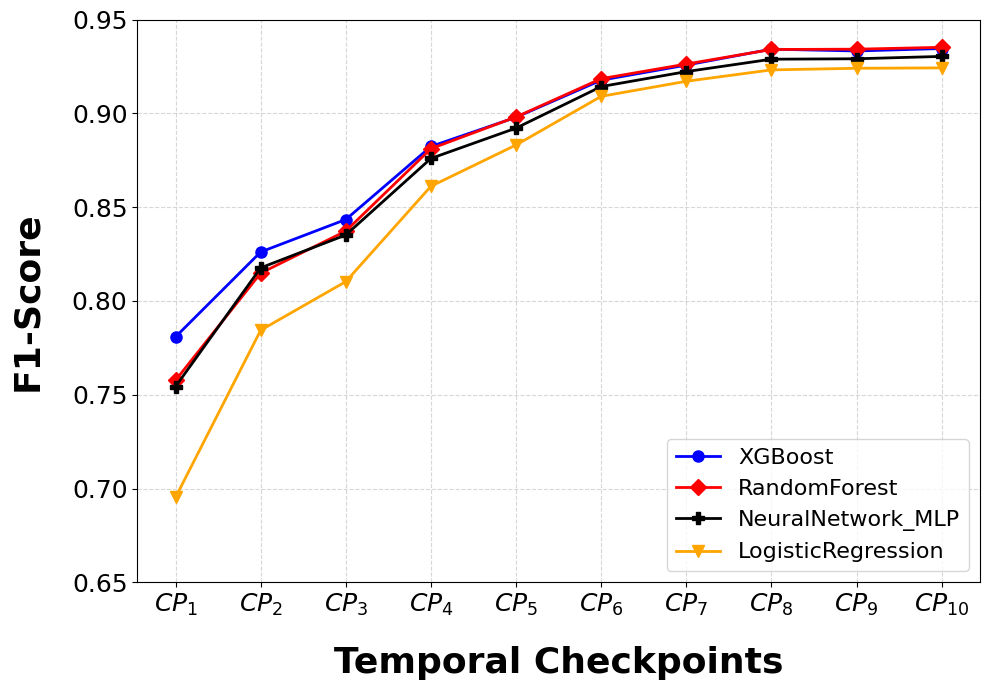

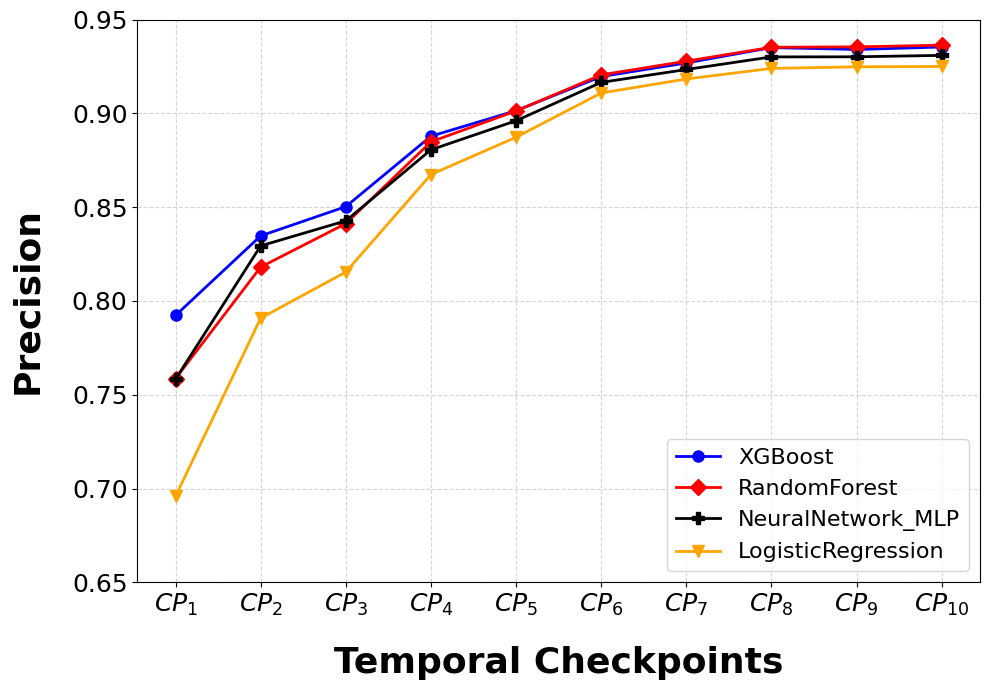

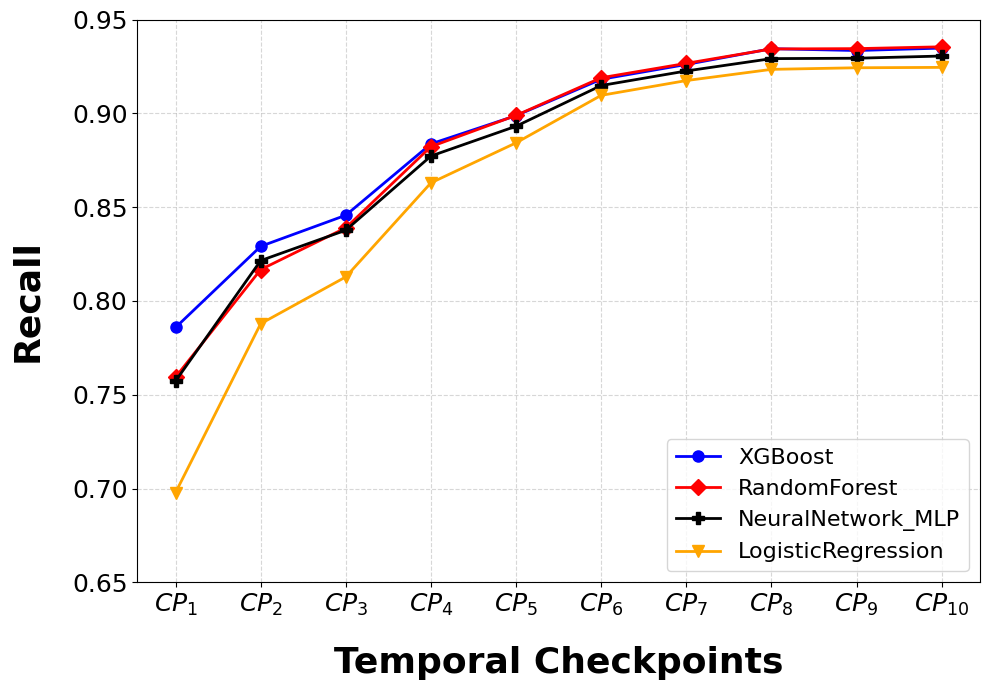

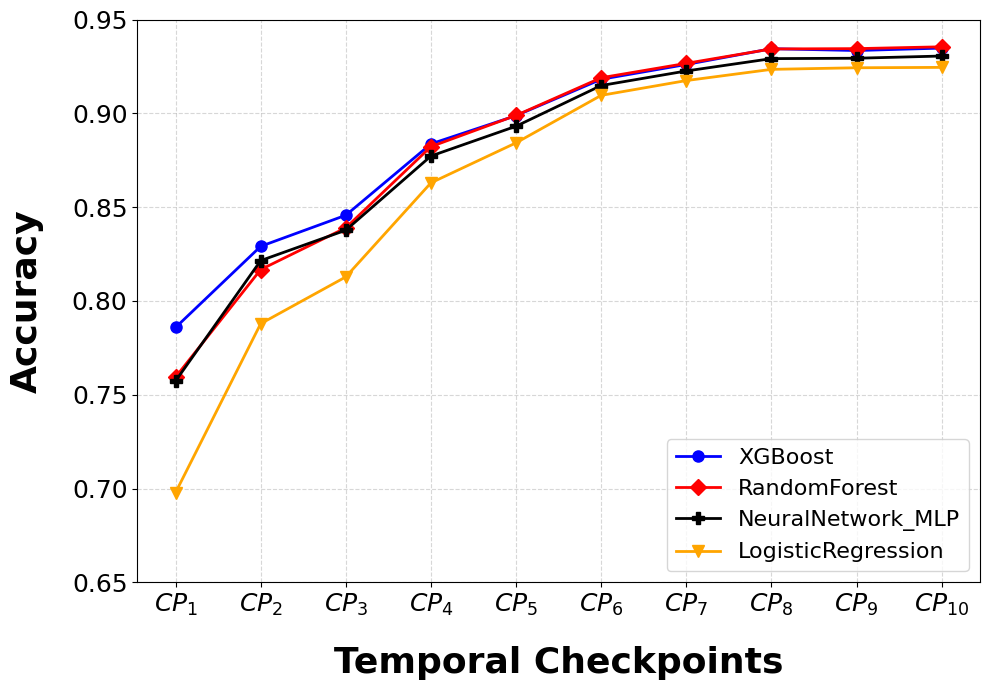

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv(OUT_TOP)
df["Model"] = df["Model"].astype(str)

model_colors = {
    "XGBoost": "blue",
    "RandomForest": "red",
    "NeuralNetwork_MLP": "black",
    "LogisticRegression": "orange",
}

model_markers = {
    "XGBoost": "o",
    "RandomForest": "D",
    "NeuralNetwork_MLP": "P",
    "LogisticRegression": "v",
}

legend_order = [
    "XGBoost",
    "RandomForest",
    "NeuralNetwork_MLP",
    "LogisticRegression",
]


def plot_metric(metric, ylabel, save_dir=None):

    plt.figure(figsize=(10,7))

    for model in legend_order:

        model_data = df[df["Model"] == model].copy()

        if model_data.empty:
            continue

        model_data = model_data.sort_values("Day_count")

        plt.plot(
            model_data["Day_count"],
            model_data[metric],
            marker=model_markers.get(model,"o"),
            color=model_colors.get(model,"black"),
            linewidth=2,
            markersize=8,
            label=model
        )

    plt.xlabel("Temporal Checkpoints", fontsize=26, fontweight="bold", labelpad=20)

    plt.ylabel(ylabel, fontsize=26, fontweight="bold", labelpad=20)

    days = sorted(df["Day_count"].unique())
    cp_labels = [f"$CP_{{{i+1}}}$" for i in range(len(days))]

    plt.xticks(days, cp_labels, fontsize=18)

    plt.ylim(0.65, 0.95)

    plt.yticks([0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95], fontsize=18)

    plt.grid(True, linestyle="--", alpha=0.5)

    plt.legend(fontsize=16, loc="lower right")

    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        filename = metric + "_over_days.eps"

        plt.savefig(
            os.path.join(save_dir, filename),
            format="eps",
            dpi=300
        )

    plt.show()


# Directory to save plots
save_dir = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/plots_selected_models"


# Plot all metrics
plot_metric("Validation_F1", "F1-Score", save_dir)

plot_metric("Validation_precision", "Precision", save_dir)

plot_metric("Validation_recall", "Recall", save_dir)

plot_metric("Validation_accuracy", "Accuracy", save_dir)

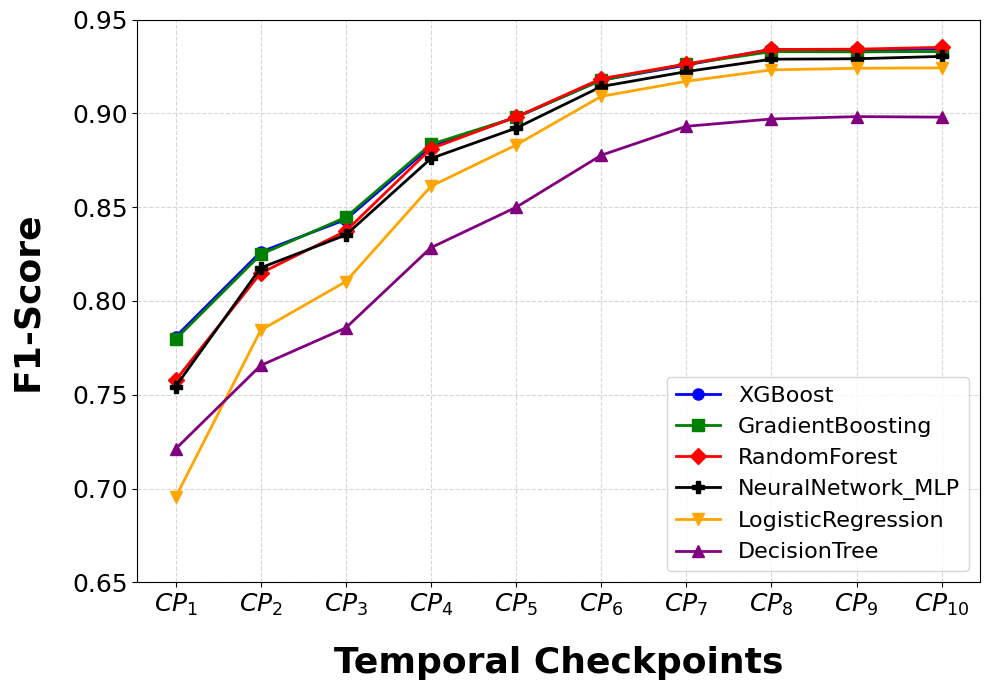

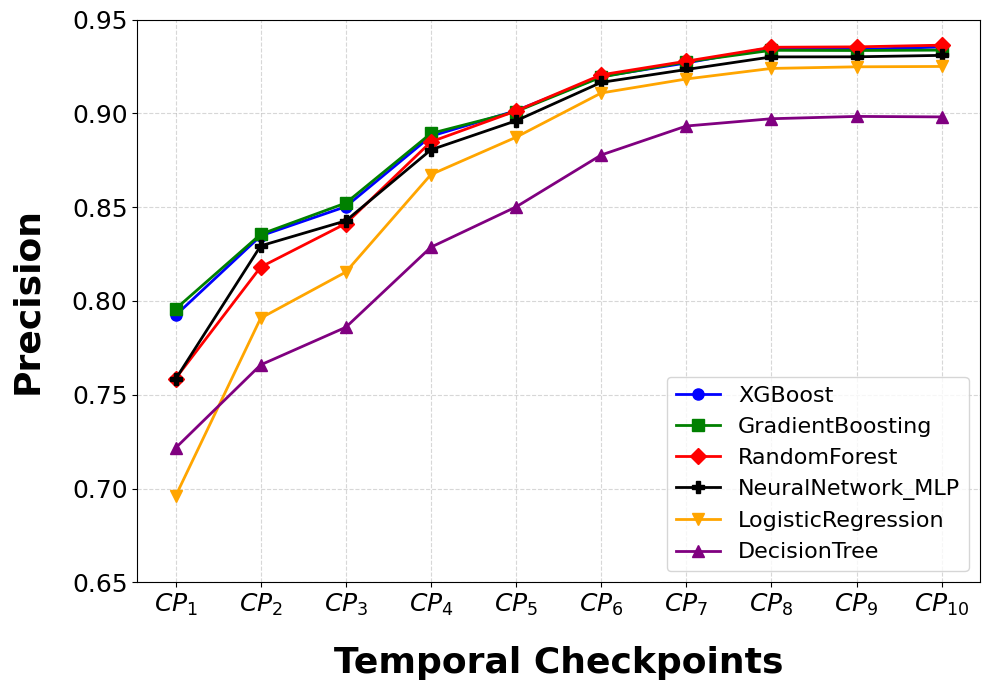

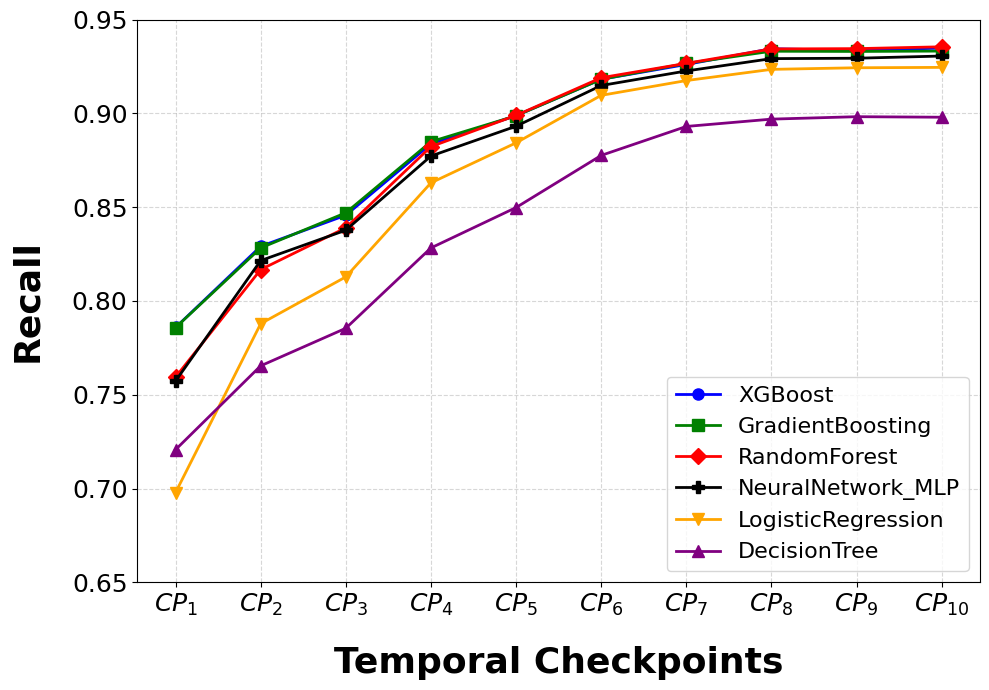

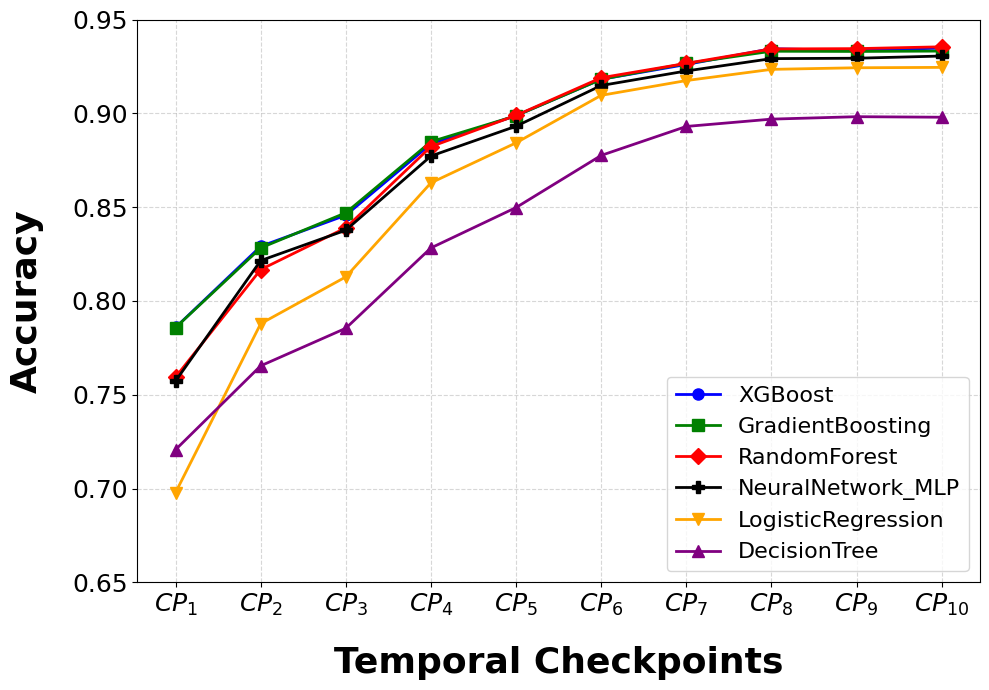

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv(OUT_TOP)
df["Model"] = df["Model"].astype(str)

model_colors = {
    "XGBoost": "blue",
    "RandomForest": "red",
    "GradientBoosting": "green",
    "LogisticRegression": "orange",
    "DecisionTree": "purple",
    "NeuralNetwork_MLP": "black",
}

model_markers = {
    "XGBoost": "o",
    "RandomForest": "D",
    "GradientBoosting": "s",
    "LogisticRegression": "v",
    "DecisionTree": "^",
    "NeuralNetwork_MLP": "P",
}

legend_order = [
    "XGBoost",
    "GradientBoosting",
    "RandomForest",
    "NeuralNetwork_MLP",
    "LogisticRegression",
    "DecisionTree",
]


def plot_metric(metric, ylabel, save_dir=None):

    plt.figure(figsize=(10,7))

    for model in legend_order:

        model_data = df[df["Model"] == model].copy()

        if model_data.empty:
            continue

        model_data = model_data.sort_values("Day_count")

        plt.plot(
            model_data["Day_count"],
            model_data[metric],
            marker=model_markers.get(model,"o"),
            color=model_colors.get(model,"black"),
            linewidth=2,
            markersize=8,
            label=model
        )


    plt.xlabel("Temporal Checkpoints", fontsize=26, fontweight="bold", labelpad=20)

    plt.ylabel(ylabel, fontsize=26, fontweight="bold", labelpad=20)

    days = sorted(df["Day_count"].unique())
    cp_labels = [f"$CP_{{{i+1}}}$" for i in range(len(days))]

    plt.xticks(days, cp_labels, fontsize=18)

    plt.ylim(0.65, 0.95)

    plt.yticks([0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95], fontsize=18)

    plt.grid(True, linestyle="--", alpha=0.5)

    plt.legend(fontsize=16, loc="lower right")

    plt.tight_layout()

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        filename = metric + "_over_days.eps"

        plt.savefig(
            os.path.join(save_dir, filename),
            format="eps",
            dpi=300
        )

    plt.show()


# Directory to save plots
save_dir = "/content/drive/MyDrive/research/ML_ALGO/AB_CP_RESULTS/plots_all_models"


# Plot all metrics
plot_metric("Validation_F1", "F1-Score", save_dir)
plot_metric("Validation_precision", "Precision", save_dir)
plot_metric("Validation_recall", "Recall", save_dir)
plot_metric("Validation_accuracy", "Accuracy", save_dir)